In [2]:
import os
import pandas as pd
import numpy as np
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import DiffusionPipeline
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import linalg
from sklearn.metrics import pairwise_distances
from torchvision.models import inception_v3

# Additional helper imports
from diffusers import StableDiffusionPipeline
from sklearn.metrics import pairwise_distances
from torchvision.models import inception_v3
import torchvision.transforms as T

C:\Users\anjit\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load dataset
csv_file = r"C:\Users\anjit\Computer Vision\photos.csv"
root_dir = r"C:\Users\anjit\Computer Vision\images"

# Read CSV
df = pd.read_csv(csv_file)

# Filter out rows where the caption or label is NaN
df = df.dropna(subset=["caption", "label"])

# Take a sample of each category to build the model
sample_size = 5000  # Adjust based on the number of images per label category
df_sampled = df.groupby('label').apply(lambda x: x.sample(min(len(x), sample_size))).reset_index(drop=True)

# Check sample data

df_sampled.head()


C:\Users\anjit\AppData\Local\Temp\ipykernel_13700\324865346.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('label').apply(lambda x: x.sample(min(len(x), sample_size))).reset_index(drop=True)


,photo_id,business_id,caption,label
0,UcI63Q8p9KcY9HvJIqbmPQ,P_x9fEz8efemqOIV46S0tg,Cucumber Margarita,drink
1,uL4aIQEiYxXwDVuhCQxrrw,aQFQIlyHasaTz5DtjV57nQ,Left Hook Lucy,drink
2,Y-K6dqLAG5gvymBHzhSEnw,ta5Oi3sezvn4H299MbtE8Q,"The famous Vieux Carre, served at the back bar...",drink
3,hD_nmFF4eBxNCdTqJKmFCw,YCHBSWYErsKAI9AXeoPxhQ,Jar Lights.,drink
4,rgAF0bdD25Bx7RTQRjhSrQ,5AOkxsg6UJQ_CoJTMBDUmQ,Lemonade Punch,drink


In [3]:
# Define a dataset class to load the images
class YelpImageDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, f"{self.dataframe.iloc[idx]['photo_id']}.jpg")
        image = Image.open(image_path).convert("RGB")
        caption = self.dataframe.iloc[idx]["caption"]
        label = self.dataframe.iloc[idx]["label"]
        
        if self.transform:
            image = self.transform(image)
        
        return image, caption, label

# Define image transformations for training
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create Dataset and DataLoader
dataset = YelpImageDataset(df_sampled, root_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


100%|████████████████████████████████████████████████████████████████████████████████| 50/50 [1:12:55<00:00, 87.52s/it]


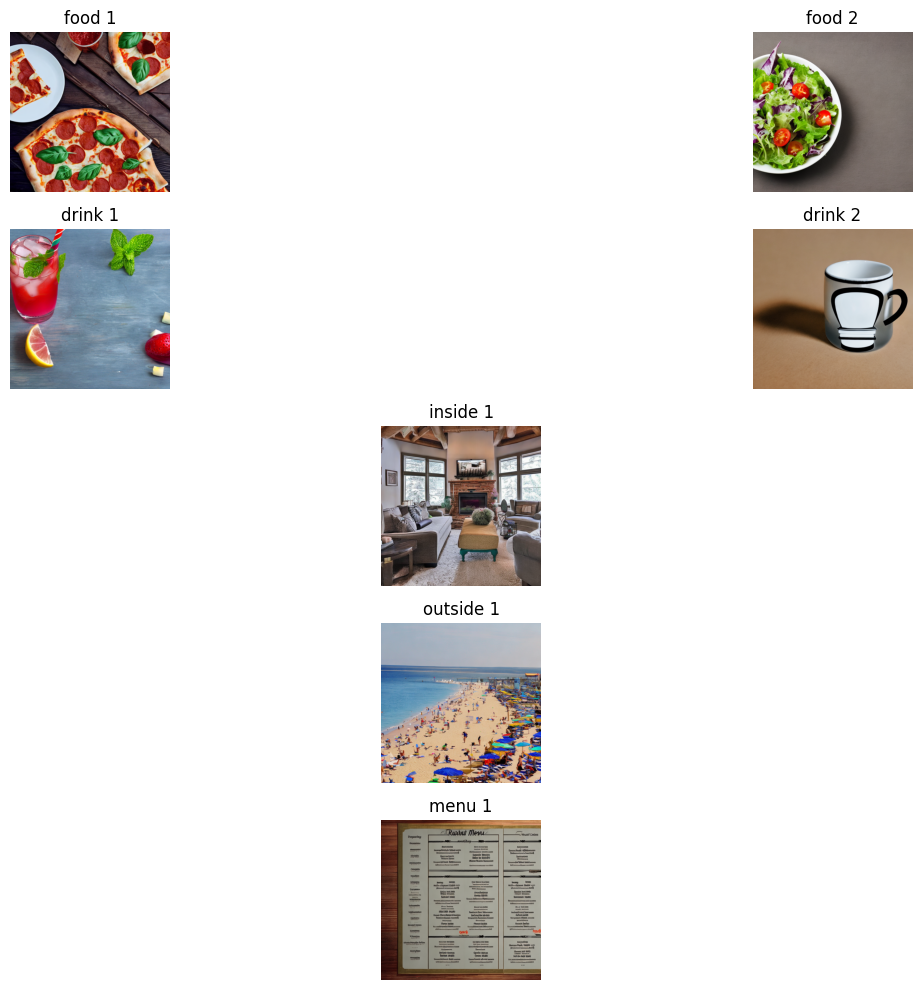

In [4]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import pandas as pd

# Load a different Stable Diffusion model from Hugging Face
pipe = StableDiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2")

# Move model to CPU (instead of CUDA)
pipe = pipe.to("cpu")

# Sample dataframe (for illustration purposes)
# df_sampled should be a pandas DataFrame with 'label' and 'caption' columns
# Example data (you should use your own dataset)
data = {
    'label': ['food', 'drink', 'inside', 'outside', 'menu', 'food', 'drink'],
    'caption': ['delicious pizza', 'cold refreshing drink', 'cozy living room', 'sunny beach', 'restaurant menu', 'fresh salad', 'coffee mug']
}
df_sampled = pd.DataFrame(data)

# Generate images for each label (sample images)
def generate_images(label, num_images=5):
    # Get the available captions for the label
    available_captions = df_sampled[df_sampled['label'] == label]['caption'].tolist()
    
    # Ensure we don't sample more than available captions
    num_images = min(num_images, len(available_captions))
    
    # Sample captions
    prompts = pd.Series(available_captions).sample(num_images, replace=False).tolist()
    
    images = []
    for prompt in prompts:
        image = pipe(prompt).images[0]
        images.append(image)
    return images

# Labels to generate images for
labels = ['food', 'drink', 'inside', 'outside', 'menu']

# Plot generated images for each label
plt.figure(figsize=(15, 10))

for idx, label in enumerate(labels):
    generated_images = generate_images(label)
    
    # Display generated images for the current label
    for i, img in enumerate(generated_images):
        plt.subplot(len(labels), len(generated_images), idx * len(generated_images) + i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'{label} {i + 1}')

plt.tight_layout()
plt.show()


In [8]:
import torch
from torchvision.models import inception_v3
import torchvision.transforms as T
import torch.nn.functional as F
import numpy as np

def calculate_inception_score(images, batch_size=32):
    # Load InceptionV3 model (CPU mode)
    inception_model = inception_v3(weights="Inception_V3_Weights.DEFAULT").eval().to("cpu")

    transform_inception = T.Compose([
        T.Resize(299),
        T.CenterCrop(299),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    def get_predictions(image_batch):
        image_batch = torch.stack([transform_inception(img) for img in image_batch]).to("cpu")  
        with torch.no_grad():
            preds = inception_model(image_batch)
        return F.softmax(preds, dim=1)  # Convert logits to probabilities

    all_preds = []
    
    # Process images in batches
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        preds = get_predictions(batch)
        all_preds.append(preds)

    # Concatenate all predictions
    all_preds = torch.cat(all_preds, dim=0).numpy()  # Convert to NumPy

    # Compute Inception Score
    p_yx = all_preds  # p(y|x)
    p_y = np.mean(p_yx, axis=0, keepdims=True)  # p(y) is the mean across all samples
    kl_div = p_yx * (np.log(p_yx) - np.log(p_y))  # Compute KL divergence
    kl_mean = np.mean(np.sum(kl_div, axis=1))  # Mean KL divergence
    inception_score = np.exp(kl_mean)  # Final Inception Score

    return inception_score

# Example usage
inception_score = calculate_inception_score(generated_images)
print("Inception Score: ", inception_score)


Inception Score:  1.0


In [4]:
import torch
from torchvision.models.inception import inception_v3
from scipy.linalg import sqrtm
from sklearn.metrics import pairwise_distances

def calculate_fid(real_images, generated_images, batch_size=32):
    # Load pretrained InceptionV3 model
    inception_model = inception_v3(pretrained=True, transform_input=False).eval().to("cuda")
    
    def get_features(images):
        # Preprocess and extract features from images
        images = torch.stack([transform_inception(img).to("cuda") for img in images])
        with torch.no_grad():
            features = inception_model(images)
        return features.view(features.size(0), -1).cpu().numpy()
    
    # Get features of real and generated images
    real_features = get_features(real_images)
    generated_features = get_features(generated_images)
    
    # Compute the FID
    mean_real, mean_generated = np.mean(real_features, axis=0), np.mean(generated_features, axis=0)
    cov_real, cov_generated = np.cov(real_features, rowvar=False), np.cov(generated_features, rowvar=False)
    
    diff = mean_real - mean_generated
    cov_sqrt, _ = sqrtm(np.dot(cov_real, cov_generated), disp=False)
    
    fid = np.sum(diff**2) + np.trace(cov_real) + np.trace(cov_generated) - 2 * np.trace(cov_sqrt)
    return fid

real_images = []
for _, row in df_sampled.iterrows():
    image_path = os.path.join(root_dir, f"{row['photo_id']}.jpg")
    try:
        with Image.open(image_path) as img:  # Auto-closes after processing
            real_images.append(img.convert("RGB"))  
    except Exception as e:
        print(f"Error loading {image_path}: {e}")

# Now use real_images in FID calculation
fid_score = calculate_fid(real_images, generated_images)
print("FID Score:", fid_score)

NameError: name 'generated_images' is not defined